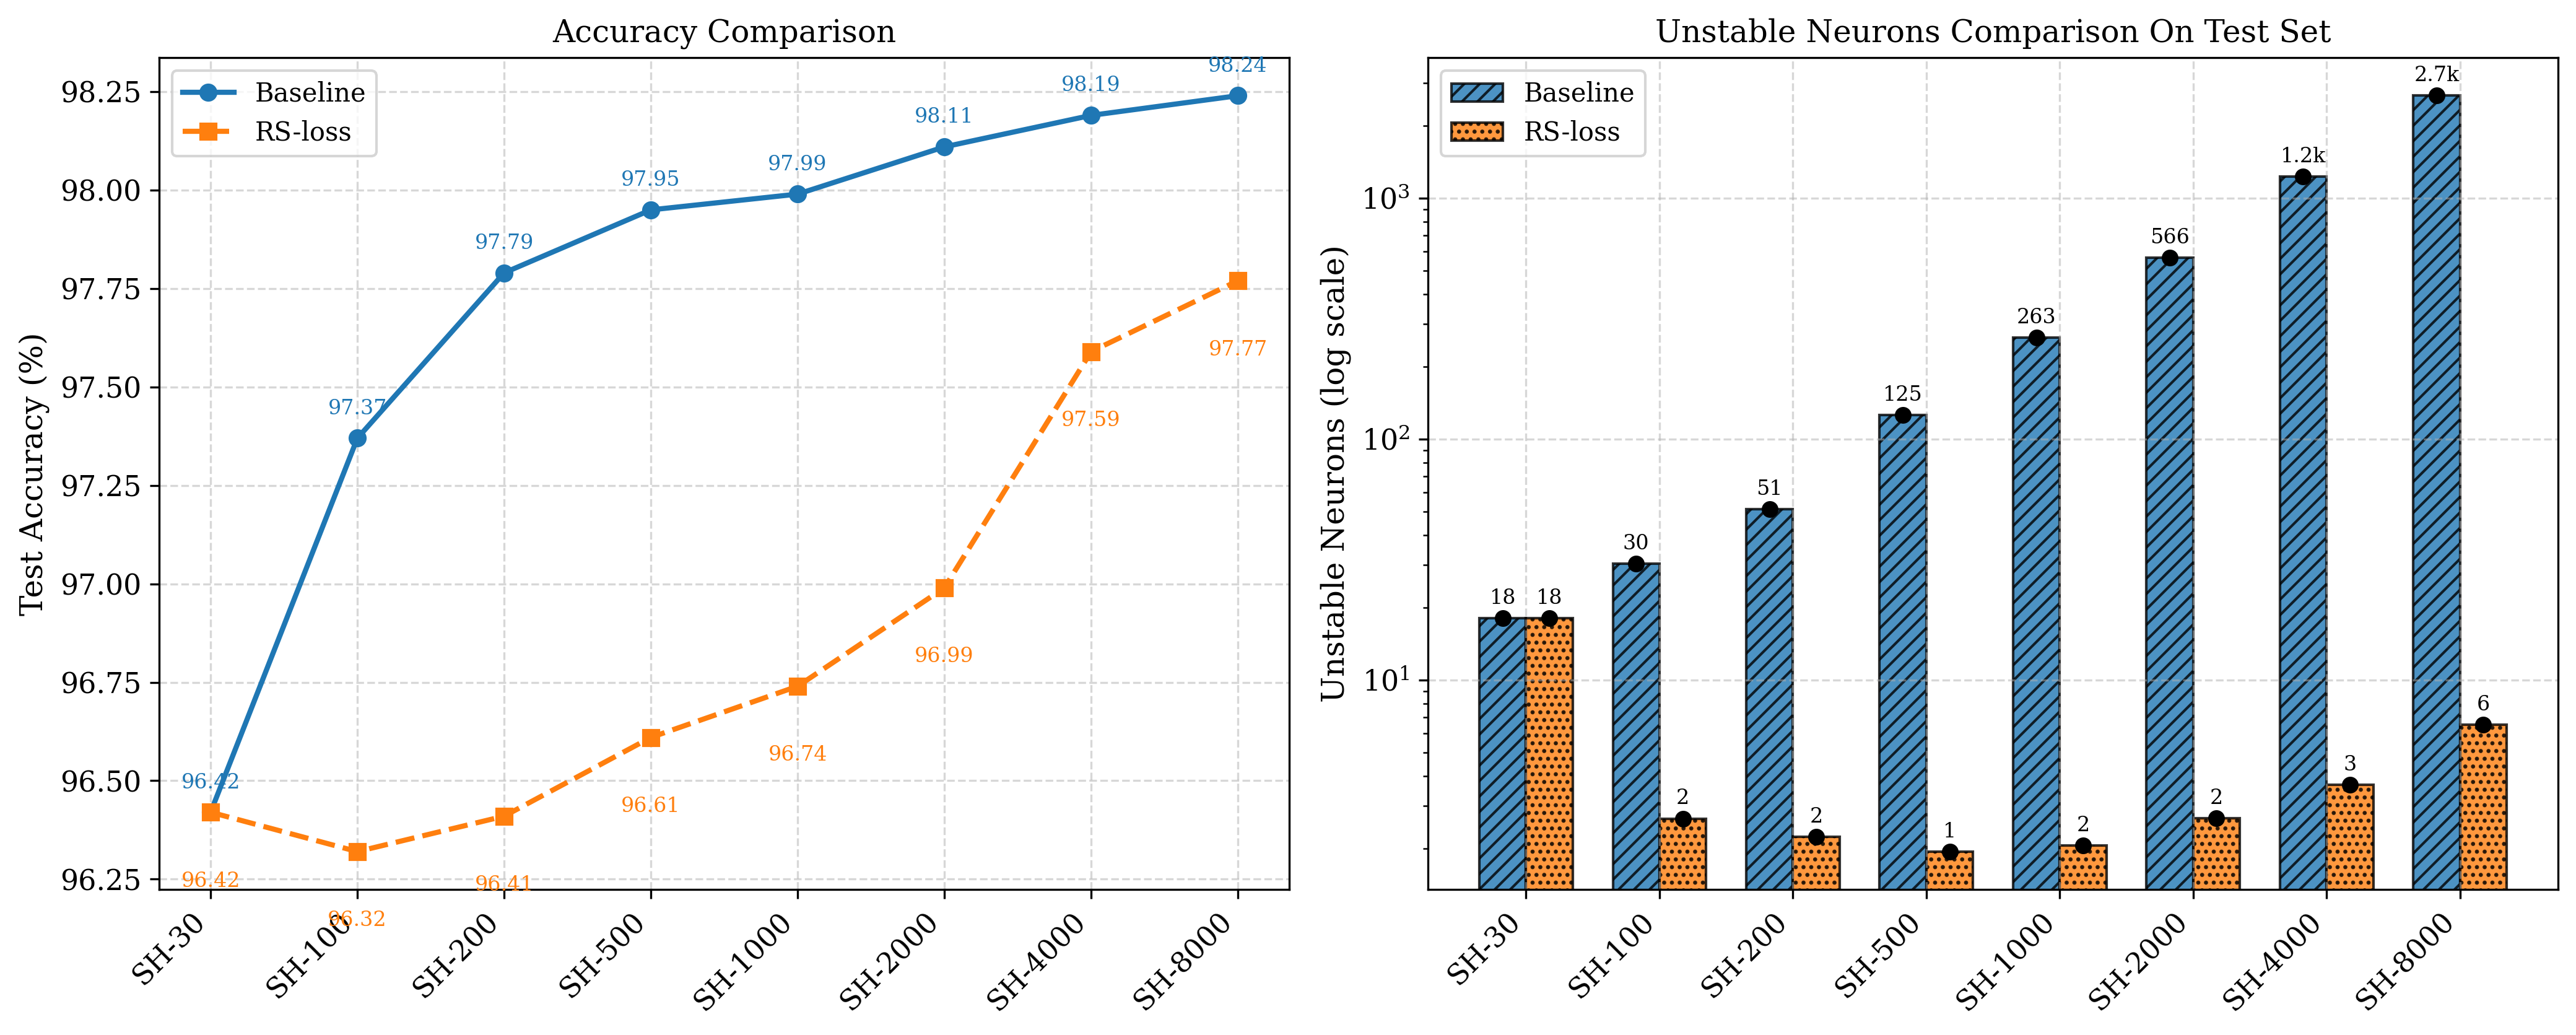

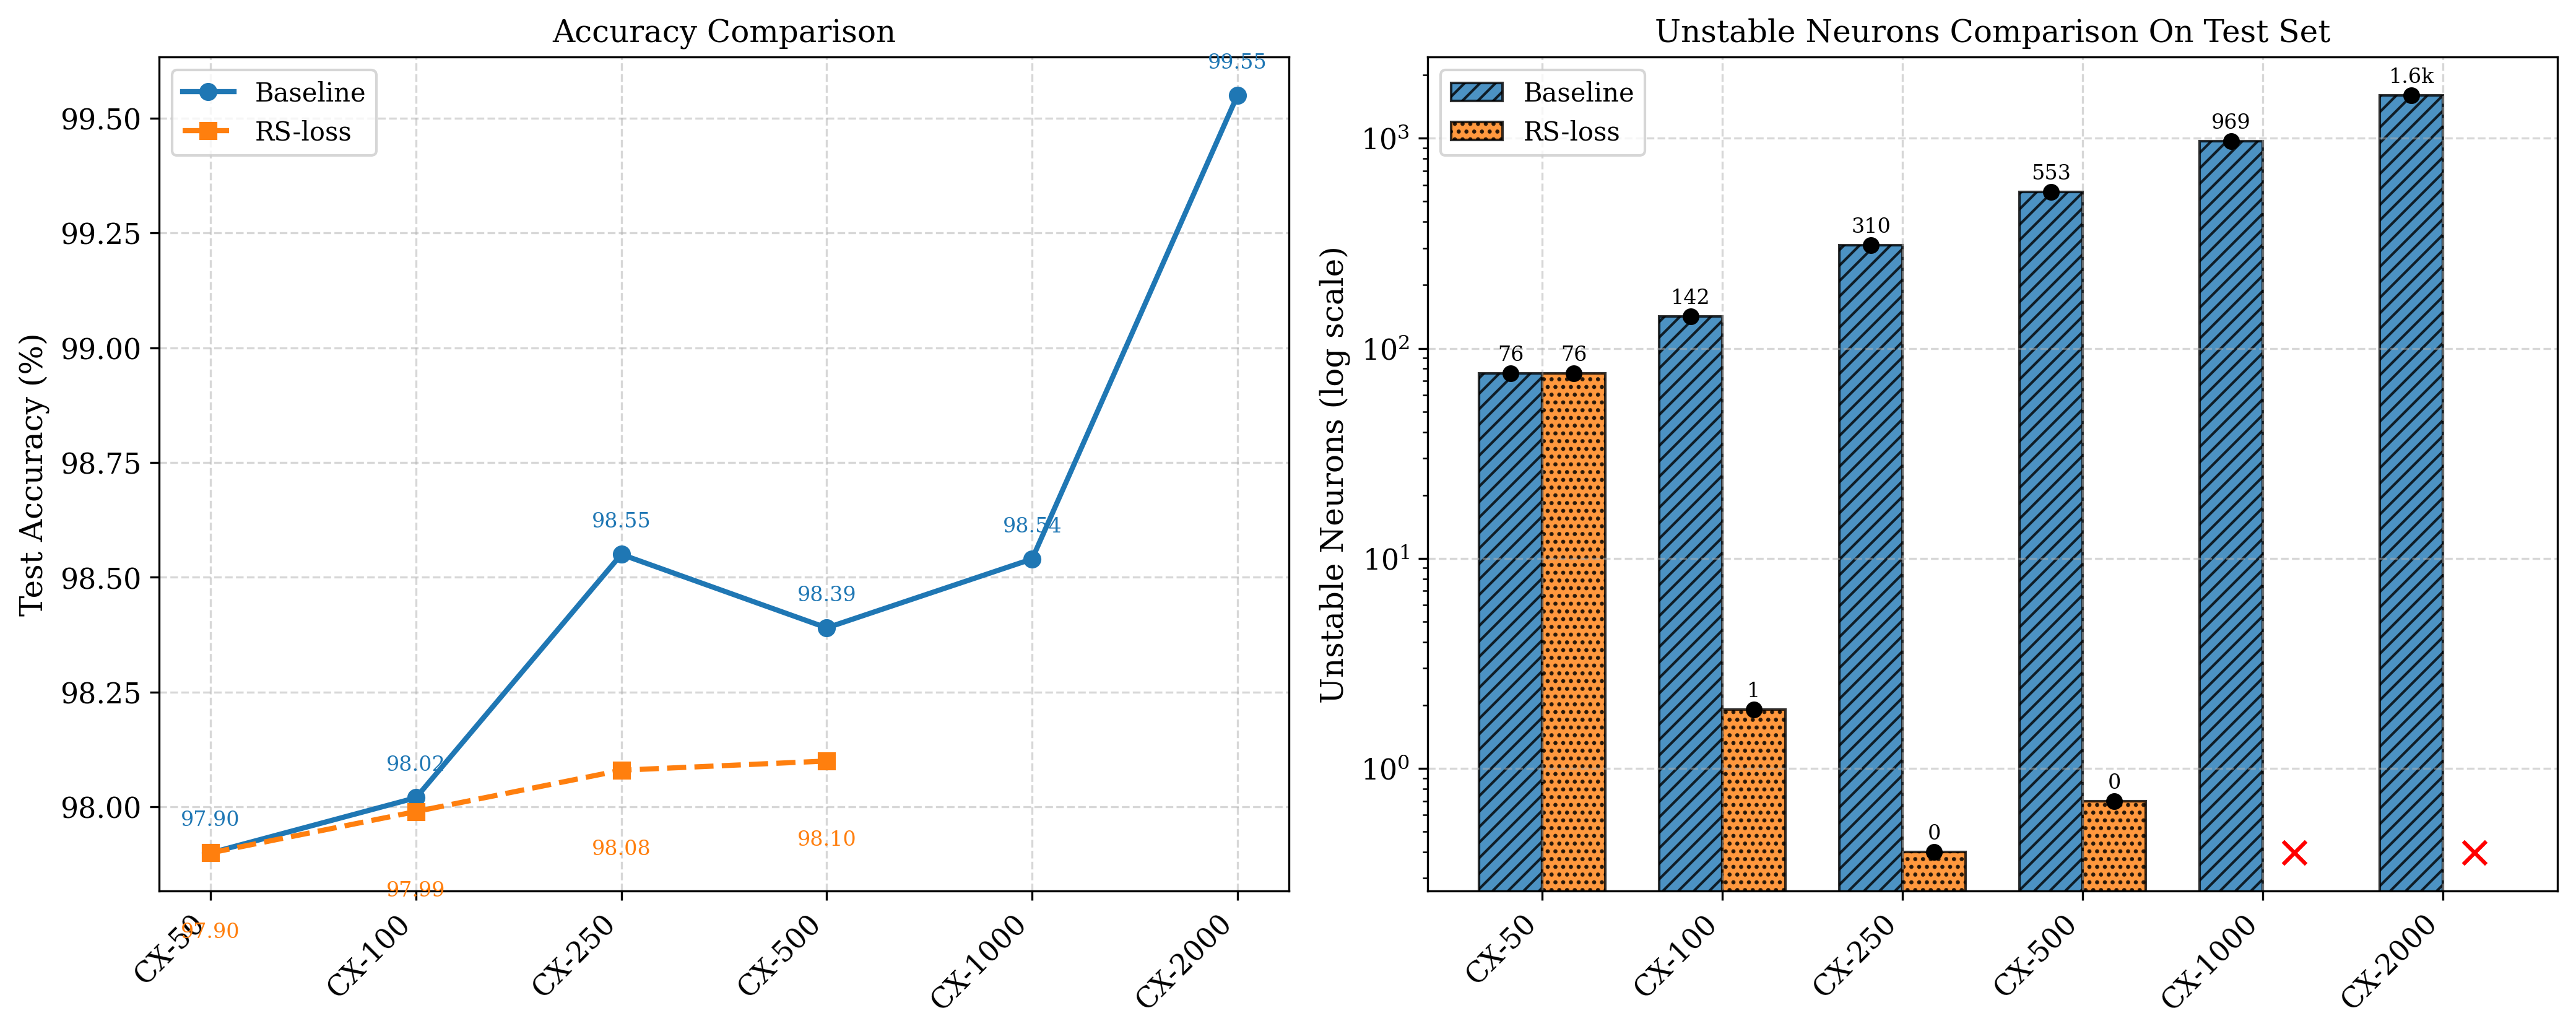

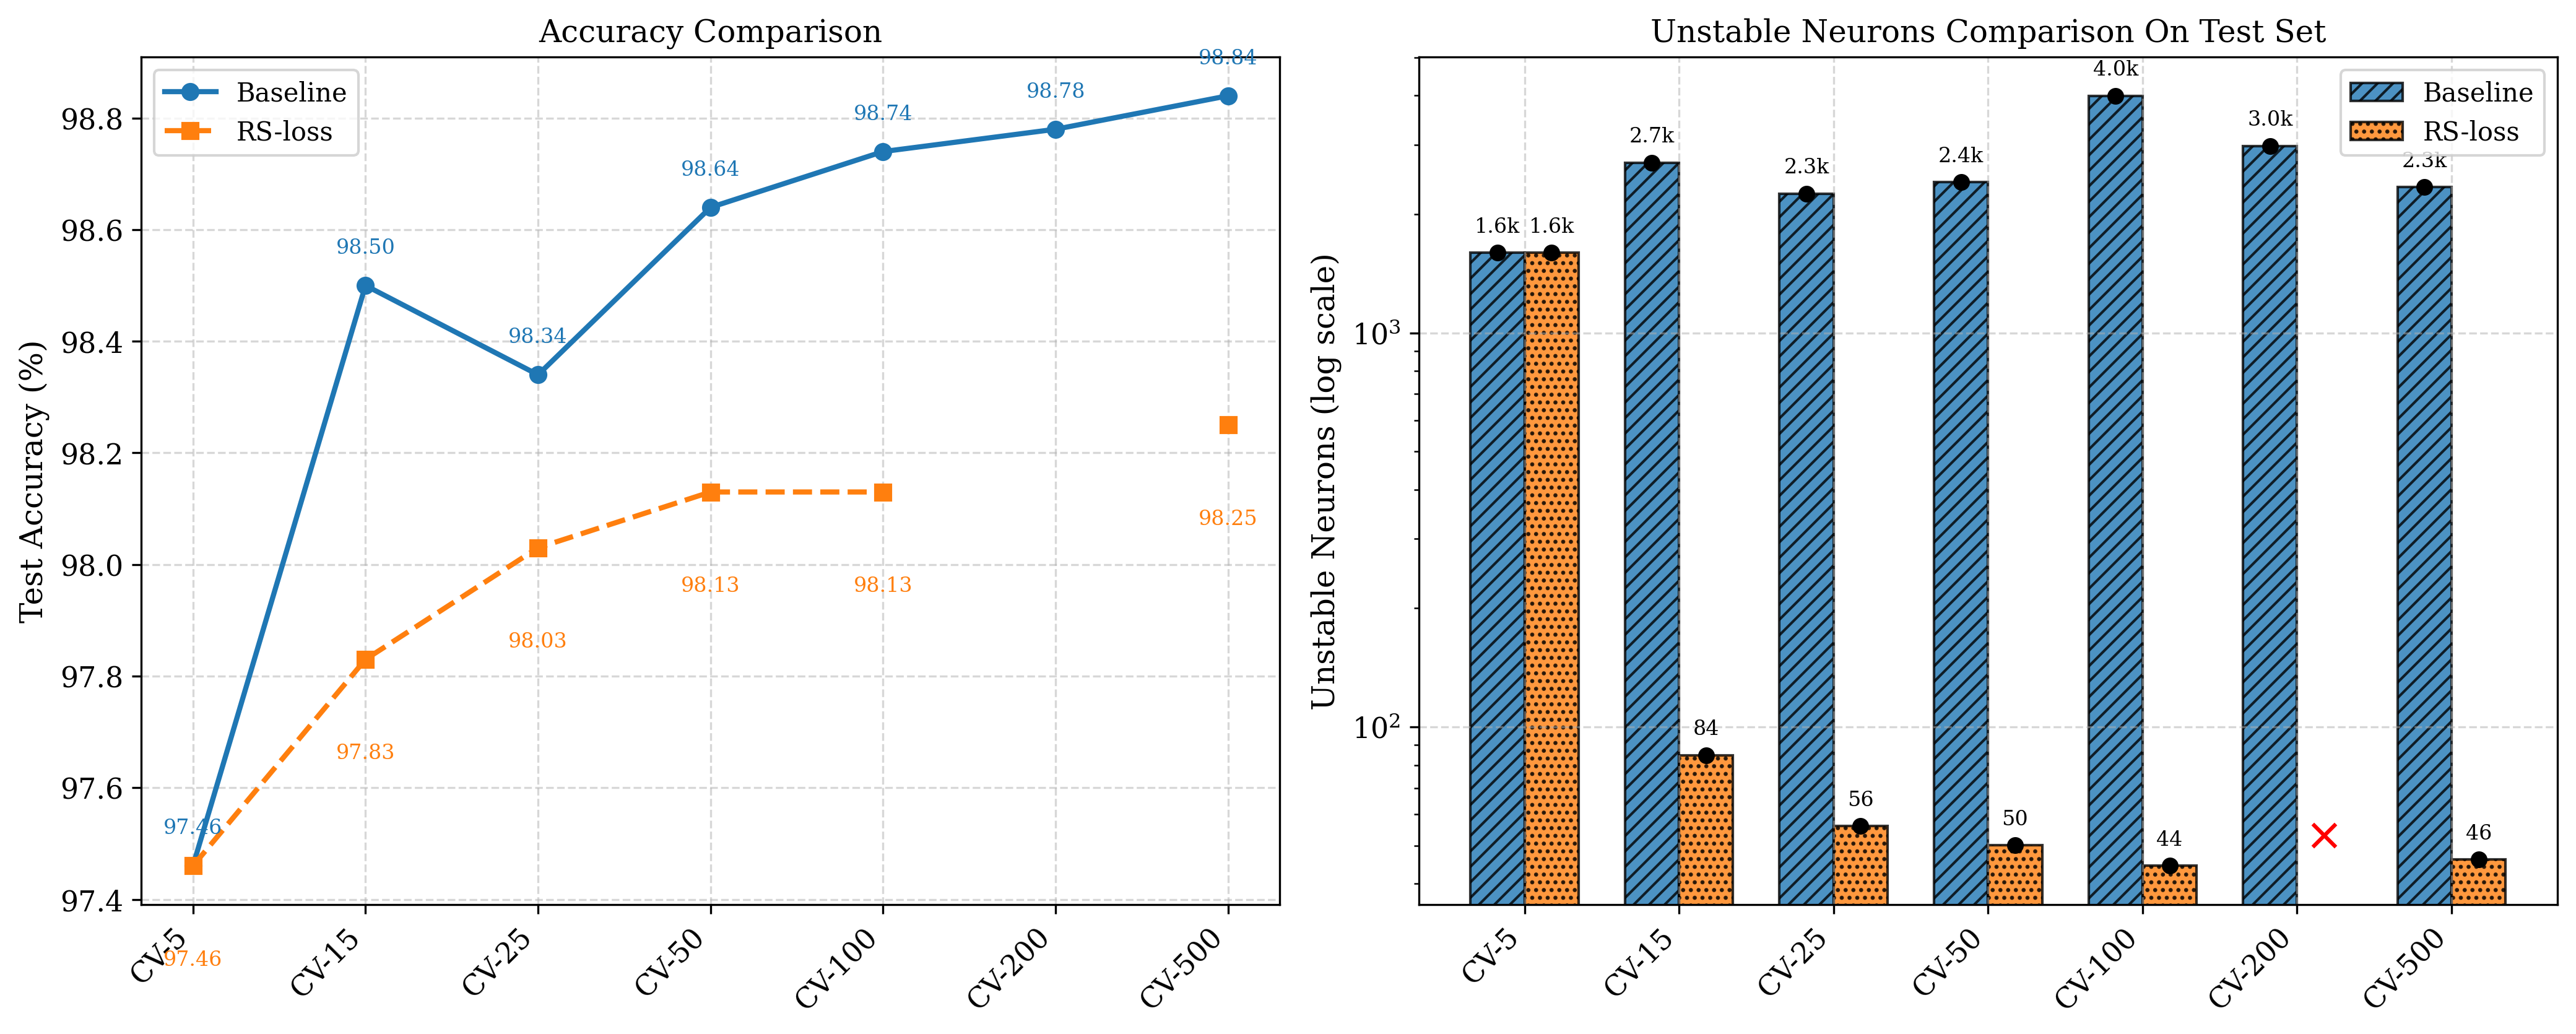

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# === DATI ===
arch_shallow = ["SH-30", "SH-100", "SH-200", "SH-500", "SH-1000", "SH-2000", "SH-4000", "SH-8000"]
acc_baseline_shallow = [96.42, 97.37, 97.79, 97.95, 97.99, 98.11, 98.19, 98.24]
acc_rs_shallow       = [96.42, 96.32, 96.41, 96.61, 96.74, 96.99, 97.59, 97.77]
unst_baseline_shallow = [18.02, 30.4, 51.1, 125.7, 263.3, 566.4, 1226.4, 2662.7]
unst_rs_shallow       = [18.02, 2.66, 2.23, 1.94, 2.06, 2.67, 3.68, 6.52]

arch_complex = ["CX-50", "CX-100", "CX-250", "CX-500", "CX-1000", "CX-2000"]
acc_baseline_complex = [97.9, 98.02, 98.55, 98.39, 98.54, 99.55]
acc_rs_complex       = [97.9, 97.99, 98.08, 98.10, np.nan, np.nan]
unst_baseline_complex = [76.1, 142.3, 310.3, 553.6, 969.2, 1604.4]
unst_rs_complex       = [76.1, 1.9, 0.4, 0.7, np.nan, np.nan]

arch_conv = ["CV-5", "CV-15", "CV-25", "CV-50", "CV-100", "CV-200", "CV-500"]
acc_baseline_conv = [97.46, 98.50, 98.34, 98.64, 98.74, 98.78, 98.84]
acc_rs_conv       = [97.46, 97.83, 98.03, 98.13, 98.13, np.nan, 98.25]
unst_baseline_conv = [1598.2, 2702.3, 2255.3, 2410.3, 3996.9, 2982.4, 2344.2]
unst_rs_conv       = [1598.2, 84.8, 56.0, 50.1, 44.4, np.nan, 46.1]

# === FUNZIONE PER PLOT ===
def plot_networks(arch, acc_base, acc_rs, unst_base, unst_rs, title, save_name):
    x = np.arange(len(arch))
    width = 0.35

    plt.figure(figsize=(14, 6))
    #plt.suptitle(title, fontsize=14, fontweight="bold")

    # --- Accuracy ---
    plt.subplot(1, 2, 1)
    plt.plot(x, acc_base, 'o-', color='C0', label="Baseline", linewidth=2, markersize=6)
    plt.plot(x, acc_rs, 's--', color='C1', label="RS-loss", linewidth=2, markersize=6)
    plt.xticks(x, arch, rotation=45, ha="right")
    plt.ylabel("Test Accuracy (%)")
    plt.title("Accuracy Comparison")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    # --- Etichette accuracy ---
    for xi, y in zip(x, acc_base):
        if not np.isnan(y):
            plt.text(xi, y + 0.05, f"{y:.2f}", ha='center', va='bottom', fontsize=8, color='C0')
    for xi, y in zip(x, acc_rs):
        if not np.isnan(y):
            plt.text(xi, y - 0.15, f"{y:.2f}", ha='center', va='top', fontsize=8, color='C1')

    # --- Neuroni instabili (bar plot log + hatches + punti) ---
    plt.subplot(1, 2, 2)
    unst_base_clean = np.nan_to_num(unst_base, nan=0)
    unst_rs_clean = np.nan_to_num(unst_rs, nan=0)

    bars1 = plt.bar(x - width/2, unst_base_clean, width, color='C0', alpha=0.8, hatch='////', edgecolor='black', label="Baseline")
    bars2 = plt.bar(x + width/2, unst_rs_clean, width, color='C1', alpha=0.8, hatch='....', edgecolor='black', label="RS-loss")

    plt.yscale("log")
    plt.xticks(x, arch, rotation=45, ha="right")
    plt.ylabel("Unstable Neurons (log scale)")
    plt.title("Unstable Neurons Comparison On Test Set")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    # Etichette barre
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                label = f"{height/1000:.1f}k" if height >= 1000 else f"{int(height)}"
                plt.text(bar.get_x() + bar.get_width()/2, height * 1.1, label, ha='center', va='bottom', fontsize=8)
                # Punto sul valore reale
                plt.scatter(bar.get_x() + bar.get_width()/2, height, color='black', zorder=10, s=30)

    add_labels(bars1)
    add_labels(bars2)

    # Mostra le X per NaN
    ymin, ymax = plt.ylim()
    offset_y = ymin * 1.5
    for xi, (yb, yr) in enumerate(zip(unst_base, unst_rs)):
        if np.isnan(yb):
            plt.scatter(x[xi] - width/2, offset_y, color='black', marker='x', s=80, zorder=10)
        if np.isnan(yr):
            plt.scatter(x[xi] + width/2, offset_y, color='red', marker='x', s=80, zorder=10)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Salvataggio
    plt.savefig(f"{save_name}.jpeg", format="jpeg", dpi=300)
    plt.show()


# === GENERA GRAFICI ===
plot_networks(arch_shallow, acc_baseline_shallow, acc_rs_shallow, unst_baseline_shallow, unst_rs_shallow, "SH Networks", "sh_networks")
plot_networks(arch_complex, acc_baseline_complex, acc_rs_complex, unst_baseline_complex, unst_rs_complex, "CX Networks", "cx_networks")
plot_networks(arch_conv, acc_baseline_conv, acc_rs_conv, unst_baseline_conv, unst_rs_conv, "CV Networks", "cv_networks")
